### Student Dropout Early-Warning Analytics — Modeling


#### Goal
Build a classification model that flags students at risk of dropping out, using only data available early in their academic journey. Compare a baseline (Logistic Regression) against a tree-based model (Random Forest). 

#### Evaluation Approach
Since this is an early-warning system, we care more about **catching at-risk students (recall on dropout class)** than perfect precision. We'll evaluate:
- ROC-AUC (overall ranking quality)
- Precision/Recall on the dropout class
- Confusion matrix at the default threshold
- Feature importance (what drives the predictions)

#### Inputs
Cleaned data from `01_eda.ipynb`, saved to `data/students_cleaned.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('data/students_cleaned.csv')
print(f'Shape: {df.shape}')
print(f'Dropout rate: {df["Dropout"].mean():.1%}')

Shape: (4424, 40)
Dropout rate: 32.1%


In [15]:
TARGET = 'Dropout'

drop_cols = [TARGET, 'Target'] 
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[TARGET]

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]}')

Features: 38
Samples: 4424


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train)} samples, {y_train.mean():.1%} dropout')
print(f'Test:  {len(X_test)} samples, {y_test.mean():.1%} dropout')

Train: 3539 samples, 32.1% dropout
Test:  885 samples, 32.1% dropout


In [17]:
# Logistic regression 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE
)
logreg.fit(X_train_scaled, y_train)

logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(f'ROC-AUC: {roc_auc_score(y_test, logreg_proba):.3f}')
print()
print(classification_report(y_test, logreg_pred, target_names=['Not Dropout', 'Dropout']))

=== Logistic Regression ===
ROC-AUC: 0.927

              precision    recall  f1-score   support

 Not Dropout       0.91      0.89      0.90       601
     Dropout       0.78      0.82      0.80       284

    accuracy                           0.87       885
   macro avg       0.85      0.86      0.85       885
weighted avg       0.87      0.87      0.87       885



Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}')
print()
print(classification_report(y_test, rf_pred, target_names=['Not Dropout', 'Dropout']))

=== Random Forest ===
ROC-AUC: 0.935

              precision    recall  f1-score   support

 Not Dropout       0.92      0.92      0.92       601
     Dropout       0.82      0.82      0.82       284

    accuracy                           0.89       885
   macro avg       0.87      0.87      0.87       885
weighted avg       0.89      0.89      0.89       885



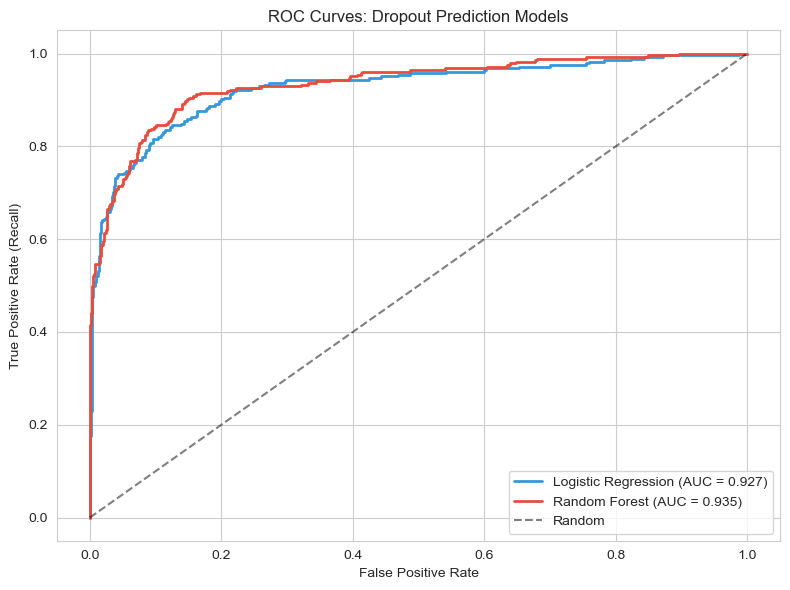

In [19]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, color in [
    ('Logistic Regression', logreg_proba, '#3498db'),
    ('Random Forest', rf_proba, '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves: Dropout Prediction Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

Confusion Matrix (Best Model)

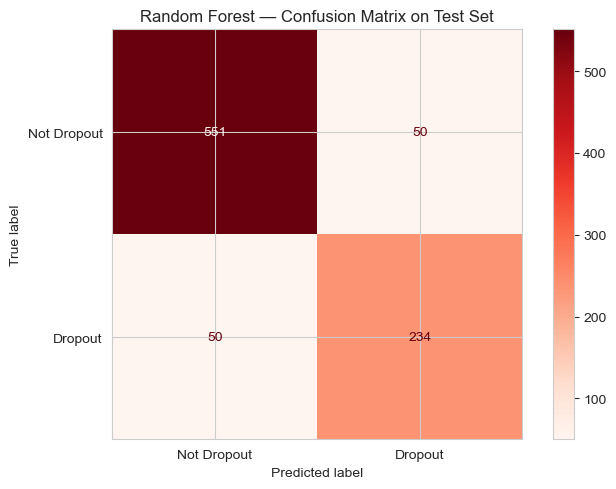

True Positives (correctly flagged at-risk): 234
False Negatives (missed at-risk students): 50
False Positives (false alarms): 50
True Negatives (correctly cleared): 551


In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, 
    display_labels=['Not Dropout', 'Dropout'],
    cmap='Reds', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix on Test Set')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
print(f'True Positives (correctly flagged at-risk): {tp}')
print(f'False Negatives (missed at-risk students): {fn}')
print(f'False Positives (false alarms): {fp}')
print(f'True Negatives (correctly cleared): {tn}')

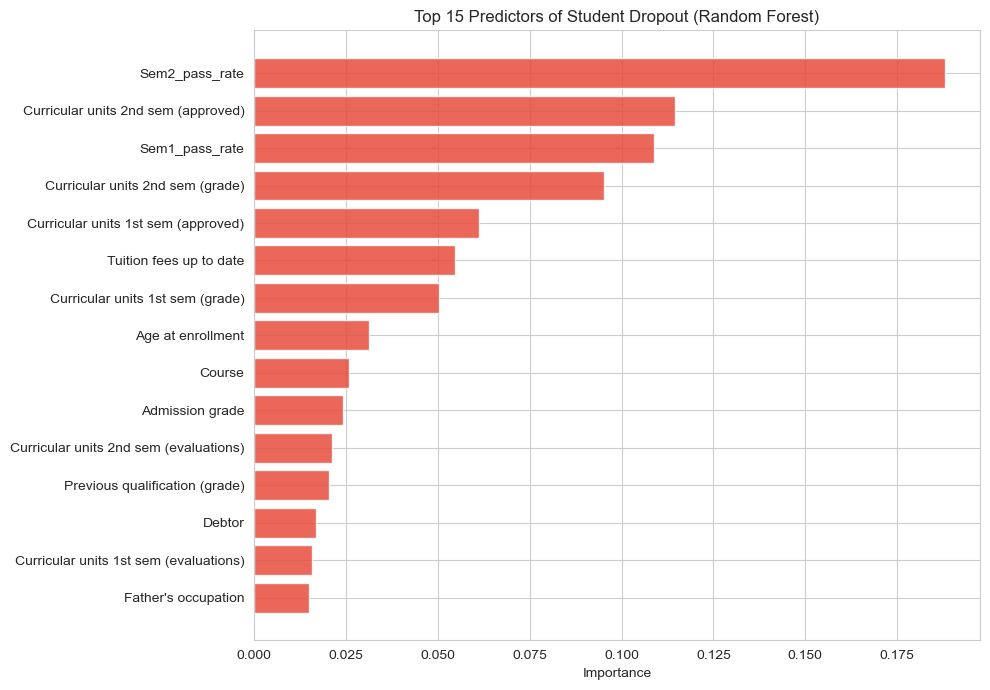


Top 10 features:
Sem2_pass_rate                         0.188
Curricular units 2nd sem (approved)    0.115
Sem1_pass_rate                         0.109
Curricular units 2nd sem (grade)       0.095
Curricular units 1st sem (approved)    0.061
Tuition fees up to date                0.055
Curricular units 1st sem (grade)       0.050
Age at enrollment                      0.031
Course                                 0.026
Admission grade                        0.024
dtype: float64


In [21]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_features = importances.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_features.index[::-1], top_features.values[::-1], color='#e74c3c', alpha=0.85)
ax.set_xlabel('Importance')
ax.set_title('Top 15 Predictors of Student Dropout (Random Forest)')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(top_features.head(10).round(3))



Translate predicted probabilities into actionable risk tiers that a student success team could use.

In [22]:
results = X_test.copy()
results['Actual_Dropout'] = y_test.values
results['Predicted_Probability'] = rf_proba
results['Risk_Tier'] = pd.cut(
    rf_proba,
    bins=[-0.01, 0.30, 0.60, 1.01],
    labels=['Low', 'Medium', 'High']
)

tier_summary = results.groupby('Risk_Tier').agg(
    Students=('Actual_Dropout', 'size'),
    Actual_Dropout_Rate=('Actual_Dropout', 'mean')
).round(3)
print(tier_summary)

# Save for Tableau
results.to_csv('outputs/test_predictions_for_tableau.csv', index=False)

           Students  Actual_Dropout_Rate
Risk_Tier                               
Low             500                0.048
Medium          139                0.353
High            246                0.858


/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_2233/1672346561.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = results.groupby('Risk_Tier').agg(


In [23]:
imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
imp_df.to_csv('outputs/feature_importance_for_tableau.csv', index=False)